In [1]:
import sys
sys.path.append('..')
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

from utils import one_hot
import selex_distribution, energy_models, tree, data_loading, training, callback, sampling, specialized_models

/home/scrotti/Aptamer2025py/experiments/../sampling.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [40]:
def hamming(x:torch.tensor, y: torch.tensor):
    L = x.size(-2)
    return L - (x * y).sum((-2, -1)).to(torch.int)

In [41]:
dtype = torch.float32

In [42]:
tr = tree.Tree()
tr.add_node(-1, name = "round 1 with selection")
tr.add_node(0, name = "round 2 with selection")

selected_modes = torch.BoolTensor(
    [[1, 0],
     [1, 0]]
)

n_selection_rounds, n_modes = selected_modes.size()
assert n_selection_rounds == tr.get_n_nodes()
n_rounds = n_selection_rounds + 1

In [43]:
L, q = 45, 4

In [44]:
generator = torch.Generator().manual_seed(1)
h_teacher = torch.randn(L, q, dtype=dtype, generator=generator)
wt_oh = sampling.sample_indep_sites(h_teacher, n_samples=1, generator=generator, beta=1.0).squeeze()
mutation_rate = 0.1
k_teacher = utils.field_from_wildtype(wt_oh, mutation_rate)
Ns0_teacher = energy_models.IndepSites(k_teacher)
sel_teacher = energy_models.IndepSites(h_teacher)
# sel.normalize()
unbound = energy_models.ConstantEnergy(-25.0)
ps_teacher = selex_distribution.MultiModeDistribution(sel_teacher, unbound, normalized=True)
model_teacher = selex_distribution.MultiRoundDistribution(Ns0_teacher, ps_teacher, tr, selected_modes)
model_teacher.train(mode=False);

## More accurate sampling

In [45]:
sample_round_zero = lambda n: sampling.sample_indep_sites(k_teacher, n)
def ps_round_t(x, t):
    return torch.exp(-ps_teacher.compute_energy(x, selected_modes[t]).detach())

total_reads = torch.tensor([0, 1, 2]) + 10**5
initial_pop_size = 10**6

In [46]:
# seq_round_zero = sample_round_zero(initial_pop_size)
# sequences, counts_round_zero = torch.unique(seq_round_zero, dim=0, return_counts=True)

In [47]:
# import timeit

# def foo(initial_pop_size):
#     seq_round_zero = sample_round_zero(initial_pop_size)
#     sequences, counts_round_zero = torch.unique(seq_round_zero, dim=0, return_counts=True)
#     return len(sequences)

# popsizes = [10**d for d in [1,2,3,4,5,6]]

# times = []
# n_unique = []
# for popsize in popsizes:
#     print(f'Measuring size {popsize}...')
#     t = %timeit -o foo(popsize)
#     times.append(t.best)
#     n = foo(popsize)
#     n_unique.append(n)

In [48]:
# plt.plot(popsizes, times, marker='o')
# plt.xlabel('Population size')
# plt.ylabel('Execution time [s]')
# plt.xscale('log')
# plt.yscale('log')

In [49]:
# plt.plot(popsizes, n_unique, marker='o')
# plt.xlabel('Population size')
# plt.ylabel('Number of unique sequences')
# plt.xscale('log')
# plt.yscale('log')

In [182]:
def read_multinomial(population, total_reads, sequences):
    reads_idx = []
    for t in range(len(population)):
        reads_t = torch.multinomial(population[t].to(torch.float), total_reads[t], replacement=True)
        reads_idx.append(reads_t)
    sequences_oh = [sequences[id] for id in reads_idx]
    
    return sequences_oh

def read_negbin(population, total_reads, sequences_unique, r):
    sequences_oh = []
    for t in range(len(population)):
        normalized_population_t = population[t] / population[t].sum()
        poisson_mean = normalized_population_t * total_reads[t]
        rt = torch.full(poisson_mean.size(), r)
        logits_t = torch.log(poisson_mean / r)
        read_counts_t = torch.distributions.negative_binomial.NegativeBinomial(rt, logits=logits_t).sample().to(torch.int)
        if not torch.all(read_counts_t >= 0):
            print(f'Found some negative counts when reading: {read_counts_t[read_counts_t<0]}')
        if torch.all(read_counts_t == 0):
            print(f'All read counts equal to zero at round {t}')
        sequences_t = torch.repeat_interleave(sequences_unique, read_counts_t, dim=0)
        sequences_oh.append(sequences_t)

    return sequences_oh

# def read_negbin(population, total_reads, sequences, r, eps=1e-8):
#     sequences_oh = []
#     for t in range(len(population)):
#         normalized_population_t = population[t].to(torch.float64) / population[t].sum()
#         poisson_mean = normalized_population_t * total_reads[t]
#         rt = torch.full(poisson_mean.size(), r)
#         # TODO: use logits instead
#         pt = torch.clamp(1 / (1 + r / poisson_mean), eps, 1-eps).to(torch.float32)
#         read_counts_t = torch.distributions.negative_binomial.NegativeBinomial(rt, pt).sample().to(torch.int)
#         if not torch.all(read_counts_t >= 0):
#             print(f'{read_counts_t[read_counts_t<0]}')
#         sequences_t = torch.repeat_interleave(sequences, read_counts_t, dim=0)
#         sequences_oh.append(sequences_t)

#     return sequences_oh

def ReadNegBin(r):
    def _read(*args):
        return read_negbin(*args, r)
    return _read

def read_poisson(population, total_reads, sequences):
    sequences_oh = []
    for t in range(len(population)):
        normalized_population_t = population[t] / population[t].sum()
        poisson_mean = normalized_population_t * total_reads[t]
        read_counts_t = torch.poisson(poisson_mean).to(torch.int)
        sequences_t = torch.repeat_interleave(sequences, read_counts_t, dim=0)
        sequences_oh.append(sequences_t)

    return sequences_oh

def generate_realistic(
    sample_round_zero,
    ps_round_t,
    initial_pop_size: int,
    n_selection_rounds: int,
    verbose = True
):
    seq_round_zero = sample_round_zero(initial_pop_size)
    if verbose: print("Extracting unique sequences and counts from initial library...")
    sequences, counts_round_zero = torch.unique(seq_round_zero, dim=0, return_counts=True)
    ps = [ps_round_t(sequences, t) for t in range(n_selection_rounds)]
    if not torch.all(torch.tensor([torch.all(pst <= 1) for pst in ps])):
        raise ValueError(f'Got some selection probabilities > 1')
    population = [counts_round_zero.to(torch.int64)]
    n_rounds = n_selection_rounds + 1
    for t in range(1, n_rounds):
        if verbose: print(f"Starting selection round {t} of {n_rounds-1}...")
        d = torch.distributions.Binomial(population[t-1], ps[t-1])
        selected = d.sample()
        if not torch.all(selected >= 0):
            raise ValueError("Binomial sampled negative values")
        amplification = 1 / ps[t-1].mean()
        population_t = (selected * amplification).to(torch.int64)
        if not torch.all(population_t >= 0):
            raise ValueError("Negative population value")
        if torch.all(population_t == 0):
            raise ValueError(f"Nothing was selected at round {t}")
        population.append(population_t)

    return population, sequences
    
def sample_realistic(
    sample_round_zero,
    ps_round_t,
    initial_pop_size: int,
    total_reads: torch.tensor,
    read = read_multinomial,
    verbose = True
):
    n_selection_rounds = len(total_reads - 1)
    population, sequences = generate_realistic(sample_round_zero, ps_round_t, initial_pop_size,
        n_selection_rounds, verbose = verbose)

    sequences_oh = read(population, total_reads, sequences)
    
    return sequences, population, sequences_oh

In [140]:
population, sequences_unique = generate_realistic(sample_round_zero, ps_round_t, initial_pop_size, n_selection_rounds)

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


In [187]:
r = 1e-4
sequences_oh = ReadNegBin(r)(population, total_reads, sequences_unique)

In [186]:
[len(s) for s in sequences_oh]

[66781, 124424, 0]

In [142]:
idx = population[1].argmax(0).item()
hamming(sequences[idx], wt_oh)

tensor(3, dtype=torch.int32)

In [143]:
[pop.to(dtype).mean() for pop in population]

[tensor(1.2263), tensor(1.1866), tensor(93.9304)]

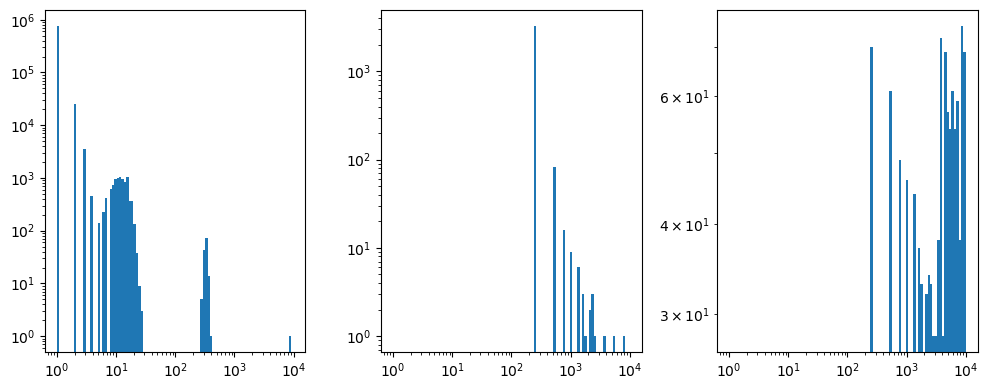

In [144]:
fig, axes = plt.subplots(1, n_rounds, figsize=(10,4))

for t in range(n_rounds):
    ax = axes[t]
    ax.hist(population[t], bins=np.logspace(0, 4, 100))
    ax.set_yscale('log')
    ax.set_xscale('log')

fig.tight_layout()

## Learn

In [ ]:
from importlib import reload
reload(data_loading)
reload(energy_models)
reload(selex_distribution)
reload(callback)
reload(training)

In [189]:
def train(sequences_oh, model_teacher):
    L, q = sequences_oh[0][0].size()
    dtype = sequences_oh[0].dtype
    n_rounds = len(sequences_oh)
    k = torch.zeros(L, q, dtype=dtype)
    h = torch.zeros(L, q, dtype=dtype)
    model = specialized_models.IndepSitesMultiRoundDistribution(k, h, n_rounds)
    model.cache_site_frequencies(sequences_oh)
    data_loaders = [data_loading.SelexRoundDataLoader(sequences_oh[t], batch_size=1) for t in range(n_rounds)]
    chains = training.init_chains(n_rounds, 1, L, q, dtype=dtype)
    callbacks = [callback.ConvergenceMetricsCallback(progress_bar=False), callback.TeacherStudentCallback(model_teacher)]
    n_sweeps = 10
    lr = 0.5
    max_epochs = 10**4
    training.train(model, data_loaders, total_reads, chains, n_sweeps, max_epochs, lr=lr, 
                   target_pearson=1-1e-5, thresh_slope=1e-4, callbacks=callbacks)

    return model, callbacks

In [146]:
model, callbacks = train(sequences_oh, model_teacher)

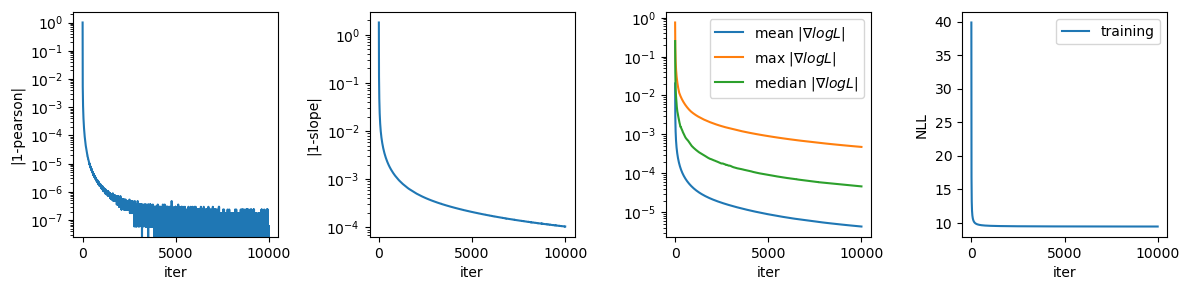

In [147]:
callbacks[0].plot();

INDEP SITES


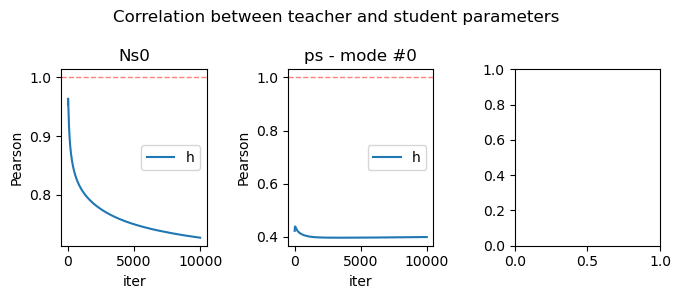

In [148]:
callbacks[1].plot(figsize=(7,3))
print('INDEP SITES')

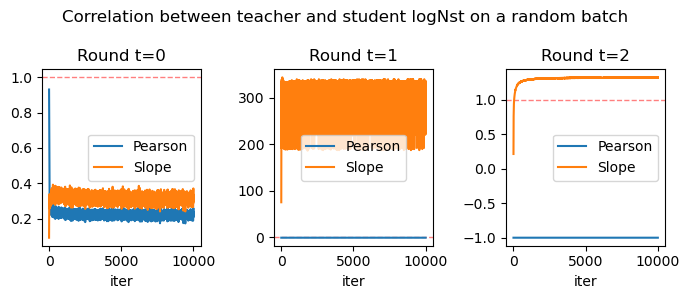

In [149]:
callbacks[1].plot_pearson_energies(figsize=(7,3));

0.7266274690628052

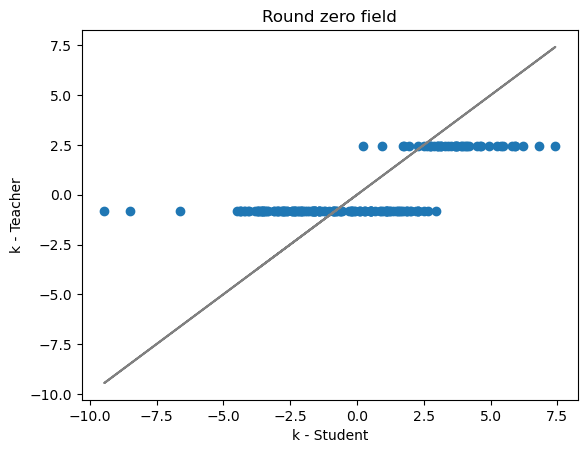

In [150]:
X = model.round_zero.set_zerosum_gauge().h.detach().reshape(-1)
Y = model_teacher.round_zero.set_zerosum_gauge().h.detach().reshape(-1)
plt.scatter(X, Y)
plt.plot(X, X, color='gray')
plt.xlabel('k - Student'); plt.ylabel('k - Teacher')
plt.title('Round zero field')
utils.compute_pearson(X, Y)

0.3993906080722809

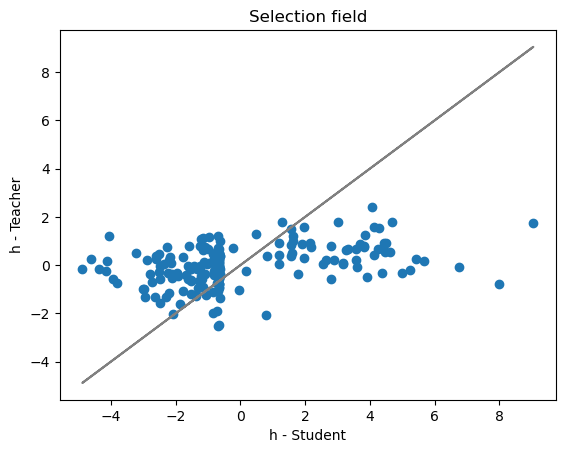

In [151]:
X = model.selection.modes[0].set_zerosum_gauge().h.detach().reshape(-1)
Y = model_teacher.selection.modes[0].set_zerosum_gauge().h.detach().reshape(-1)
plt.scatter(X, Y)
plt.plot(X, X, color='gray')
plt.xlabel('h - Student'); plt.ylabel('h - Teacher')
plt.title('Selection field')
utils.compute_pearson(X, Y)

## Effect of negative binomial

In [152]:
sample_round_zero = lambda n: sampling.sample_indep_sites(k_teacher, n)
def ps_round_t(x, t):
    return torch.exp(-ps_teacher.compute_energy(x, selected_modes[t]).detach())

total_reads = torch.tensor([0, 1, 2]) + 10**5
initial_pop_size = 10**6

In [153]:
population, sequences_unique = generate_realistic(sample_round_zero, ps_round_t, initial_pop_size, n_selection_rounds)

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


In [176]:
def read_and_train_multinomial(population, sequences_unique, total_reads, model_teacher):
    sequences_oh = read_multinomial(population, total_reads, sequences_unique)
    model, callbacks = train(sequences_oh, model_teacher)
    
    return model, callbacks

def read_and_train_negbin(population, sequences_unique, total_reads, model_teacher, r):
    sequences_oh = ReadNegBin(r)(population, total_reads, sequences_unique)
    model, callbacks = train(sequences_oh, model_teacher)
    
    return model, callbacks

def read_and_train_poisson(population, sequences_unique, total_reads, model_teacher):
    sequences_oh = read_poisson(population, total_reads, sequences_unique)
    model, callbacks = train(sequences_oh, model_teacher)
    
    return model, callbacks

In [161]:
model_multinom, callbacks_multinom = read_and_train_multinomial(population, sequences_unique, total_reads, model_teacher)

In [162]:
model_poisson, callbacks_poisson = read_and_train_poisson(population, sequences_unique, total_reads, model_teacher)

In [168]:
sequences_oh = ReadNegBin(r)(population, total_reads, sequences_unique)

In [188]:
rs = [10, 100, 1000, 10**4, 10**5, 10**6, 10**7]
rs = [5, 10, 20, 50, 100, 500, 1000, 10**4]
rs = torch.logspace(-4, 0.2, 10)

models_negbin = []
callbacks_negbin = []

for r in rs:
    m, c = read_and_train_negbin(population, sequences_unique, total_reads, model_teacher, r)
    models_negbin.append(m)
    callbacks_negbin.append(c)
    print(f'r={r} finished\n')

[65576, 48754, 11999]
r=9.999999747378752e-05 finished

[86940, 27445, 11959]
r=0.00029286445351317525 finished

[97745, 131556, 85734]
r=0.0008576958207413554 finished

[102298, 73785, 127673]
r=0.0025118859484791756 finished

[95868, 115885, 94119]
r=0.007356421090662479 finished

[96777, 94328, 108750]
r=0.021544352173805237 finished

[102033, 99414, 97366]
r=0.06309574097394943 finished

[103312, 103298, 103688]
r=0.18478499352931976 finished

[102446, 103397, 105465]
r=0.5411695837974548 finished

[99236, 100649, 98280]
r=1.5848932266235352 finished



In [190]:
def extract_pearsons(callbacks):
    return callbacks[1].pearson_Ns0[-1][0], callbacks[1].pearson_ps[-1][0][0]

r=9.999999747378752e-05
r=0.00029286445351317525
r=0.0008576958207413554
r=0.0025118859484791756
r=0.007356421090662479
r=0.021544352173805237
r=0.06309574097394943
r=0.18478499352931976
r=0.5411695837974548
r=1.5848932266235352


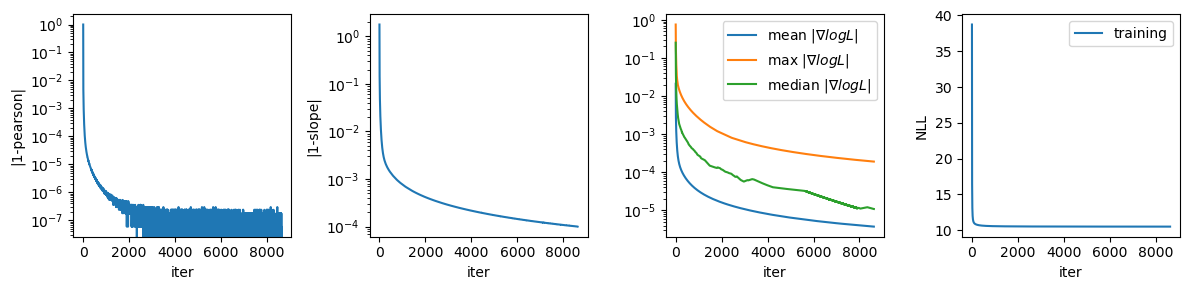

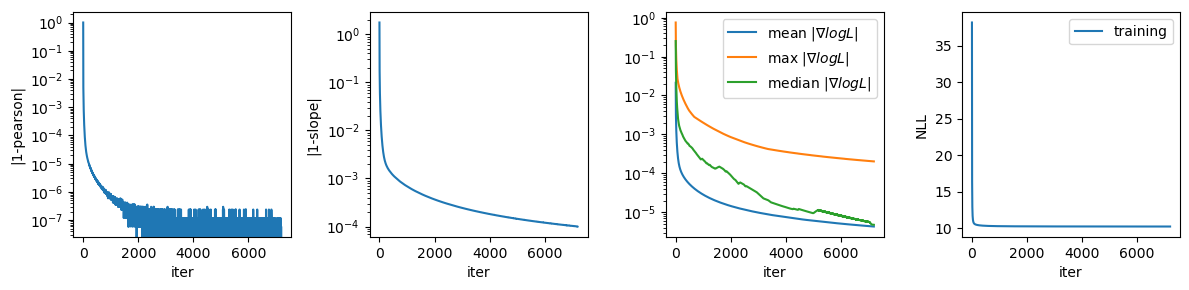

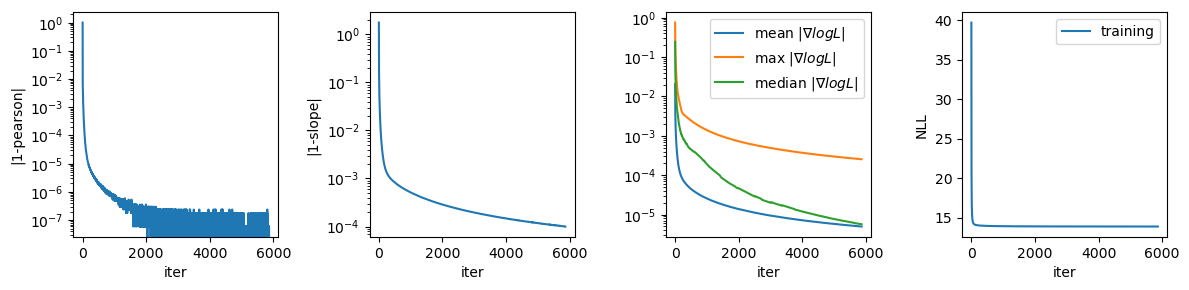

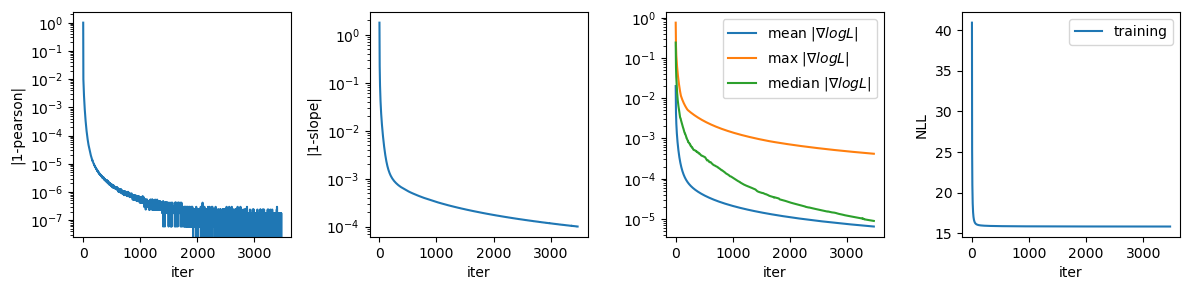

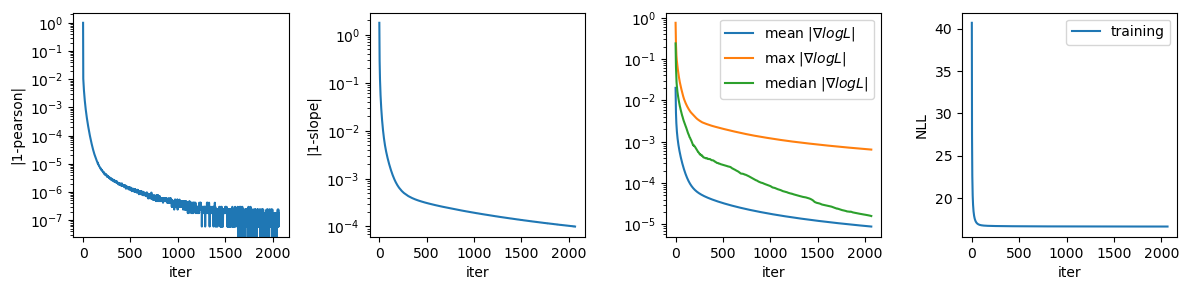

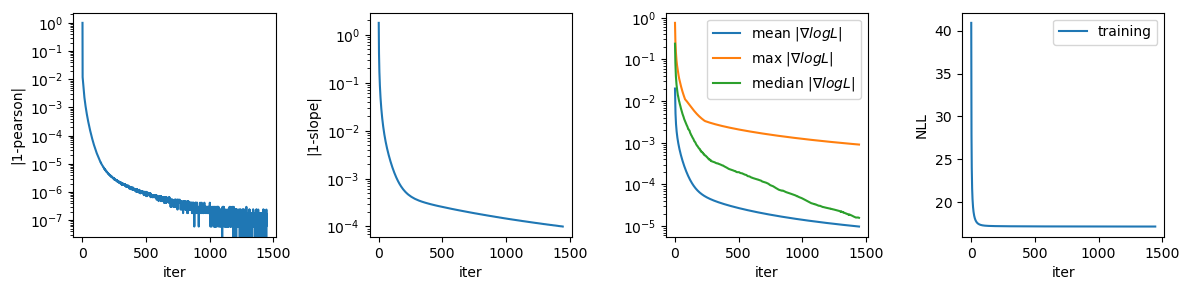

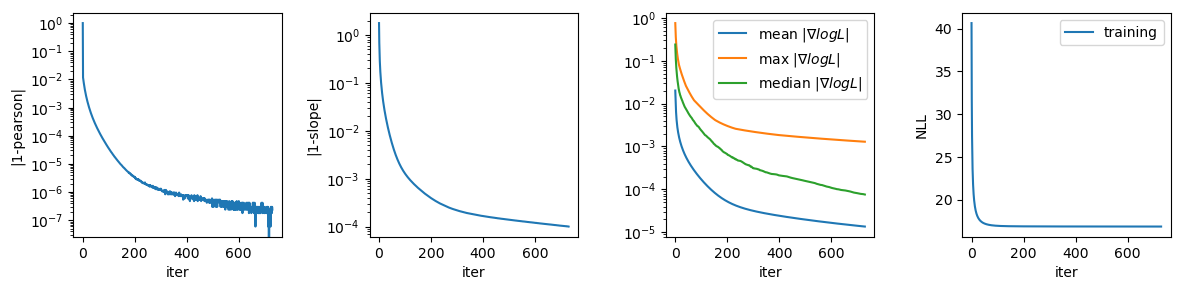

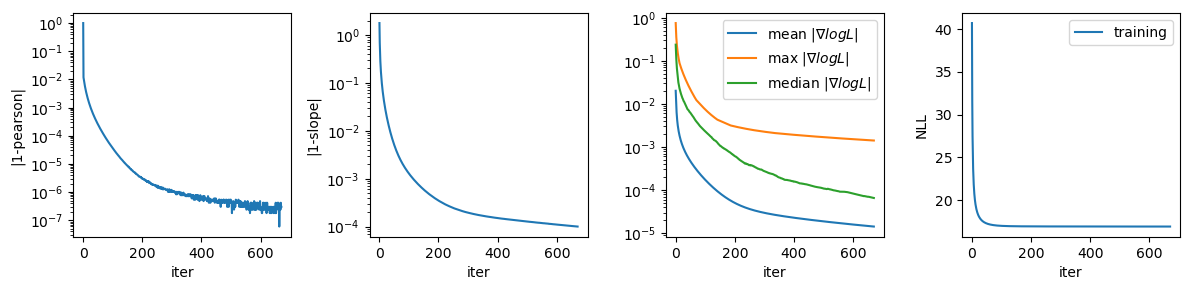

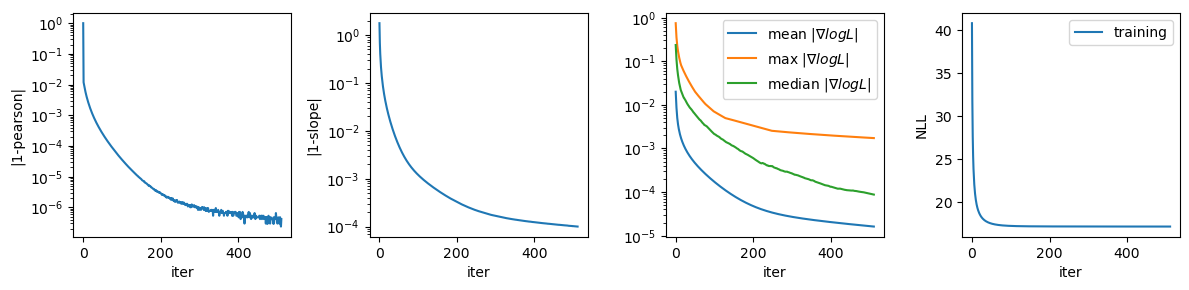

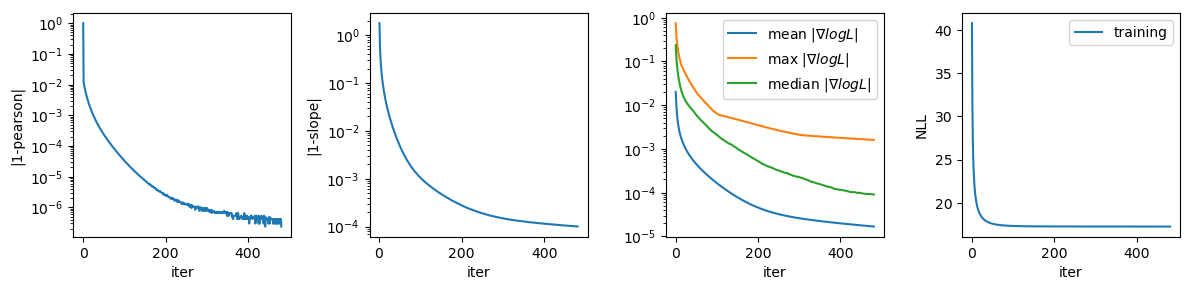

In [191]:
for (r, callbacks) in zip(rs, callbacks_negbin):
    print(f'r={r}')
    callbacks[0].plot()

In [192]:
pearson_multinom = extract_pearsons(callbacks_multinom)
pearson_poisson = extract_pearsons(callbacks_poisson)
pearson_negbin = [extract_pearsons(c) for c in callbacks_negbin]

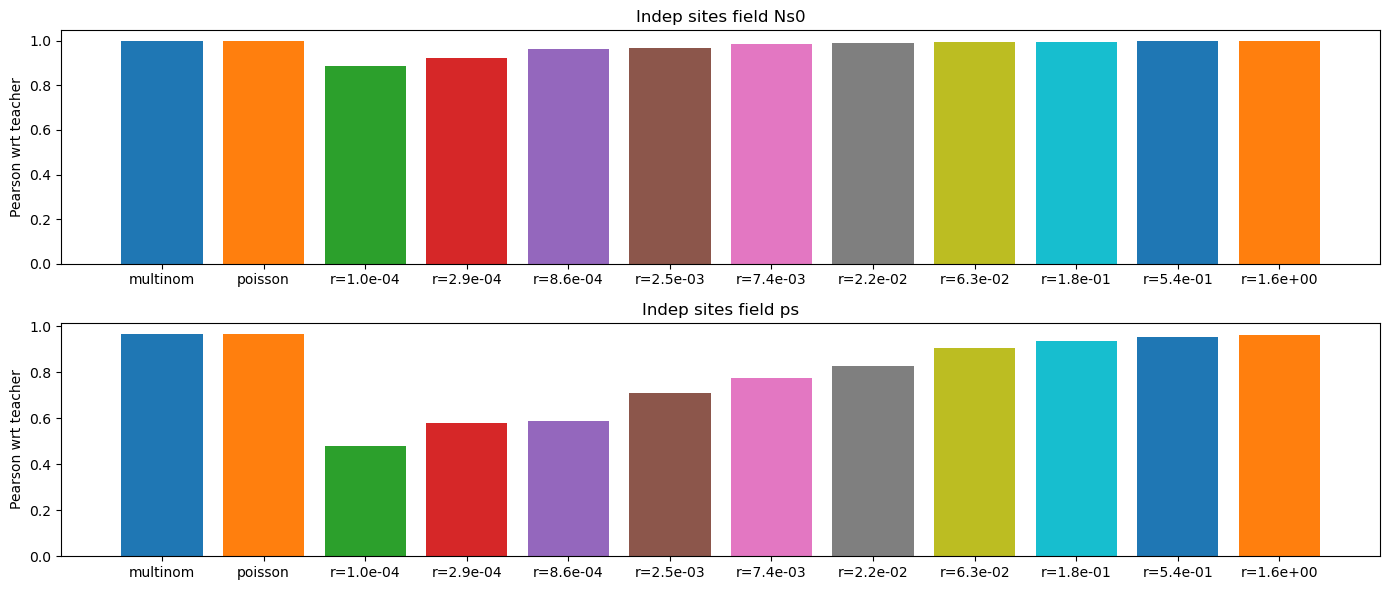

In [194]:
fig, axes = plt.subplots(2,1, figsize=(14,6))

y = ['Ns0', 'ps']
for i in range(2):
    ax = axes[i]
    ax.bar(['multinom'], pearson_multinom[i])
    ax.bar(['poisson'], pearson_poisson[i])
    for a in range(len(pearson_negbin)):
        ax.bar([f'r={rs[a]:.1e}'], pearson_negbin[a][i])
    ax.set_ylabel(f'Pearson wrt teacher')
    ax.set_title(f'Indep sites field {y[i]}')
fig.tight_layout()

## Compare against data

In [44]:
sequences_unique_all_oh, counts_unique, enrichments = utils.group_rounds(sequences_oh, return_enrichments=True)

Extracting unique sequences and counts at each round...
Merging sequences from all rounds in a single container...
Assigning counts at each round to unique sequences...
	Starting round 0...
	Starting round 1...
	Starting round 2...
Calculating enrichments...
Finished


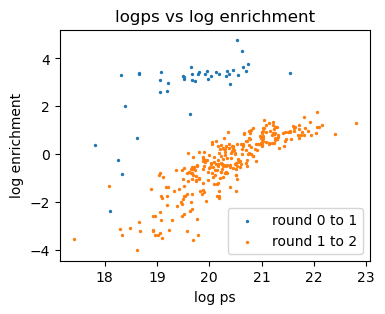

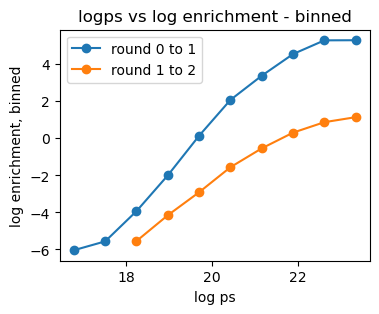

In [45]:
utils.binned_logenrichments(model, sequences_unique_all_oh, enrichments, counts_unique, n_bins = 25, plot=True, thresh=0.0);

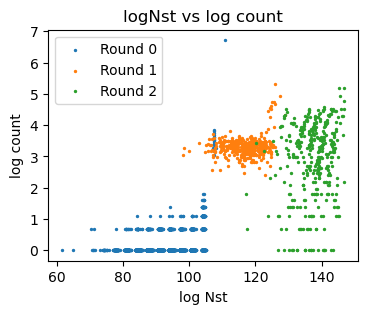

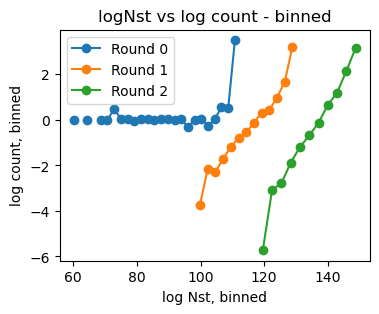

In [46]:
utils.binned_logcounts(model, sequences_unique_all_oh, counts_unique, n_bins = 25, plot=True, thresh=0.0);